# 📊 Bank Marketing Term Deposit Prediction – Feature Engineering & Feature Selection
# Problem Statement

Banks run marketing campaigns to encourage customers to subscribe to term deposits. 
Predicting likely responders is difficult because raw features may not capture 
interactions or non-linear relationships.

Feature engineering allows us to create new features, highlight important patterns, 
and potentially improve model performance.

# Objective

- Engineer new features (polynomial, interaction, binning)
- Select important features (correlation, tree-based importance, RFE)
- Train best model (XGBoost) with new features
- Compare performance before and after feature engineering

# STEP 1: Import Required Libraries

In [19]:
# ===============================
#  Import Required Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# STEP 2: Load Dataset

In [20]:
# ===============================
#  Load Dataset
# ===============================

# Load dataset
df = pd.read_csv("bank.csv", sep=';')

# Display dataset shape
print("Dataset shape:", df.shape)

# Show first 5 rows
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (41188, 21)

First 5 rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.

# STEP 3: Data Preprocessing

In [21]:
# ===============================
# Data Preprocessing
# ===============================

# Convert target variable to binary
df['y'] = df['y'].map({'yes':1,'no':0})

# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Print shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (41188, 20)
Target shape: (41188,)


# STEP 4: Train Test Split

In [22]:
# ===============================
#  Train Test Split
# ===============================

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32950, 20)
Testing data: (8238, 20)


# STEP 5: One-Hot Encoding

In [23]:
# ===============================
#  One-Hot Encoding
# ===============================

# Convert categorical variables to numeric
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded dataset shape:", X_encoded.shape)

print("\nSample columns:")
print(X_encoded.columns[:10])

Encoded dataset shape: (41188, 53)

Sample columns:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


# STEP 6: Baseline Model (Before Feature Engineering)

In [34]:
# ===============================
# Baseline Model (Before Feature Engineering)
# ===============================

# Split original encoded dataset
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to numpy (avoids XGBoost dataframe issues)
X_train_base = X_train_base.values
X_test_base = X_test_base.values
y_train_base = y_train_base.values
y_test_base = y_test_base.values

# Train baseline XGBoost model
baseline_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

baseline_model.fit(X_train_base, y_train_base)

# Predictions
y_pred_base = baseline_model.predict(X_test_base)
y_prob_base = baseline_model.predict_proba(X_test_base)[:,1]

# Evaluation metrics
acc_before = accuracy_score(y_test_base, y_pred_base)
prec_before = precision_score(y_test_base, y_pred_base)
rec_before = recall_score(y_test_base, y_pred_base)
f1_before = f1_score(y_test_base, y_pred_base)
roc_before = roc_auc_score(y_test_base, y_prob_base)

print("Baseline Model Performance (Before Feature Engineering)\n")

print("Accuracy:", acc_before)
print("Precision:", prec_before)
print("Recall:", rec_before)
print("F1 Score:", f1_before)
print("ROC AUC:", roc_before)

Baseline Model Performance (Before Feature Engineering)

Accuracy: 0.9174556931294003
Precision: 0.658974358974359
Recall: 0.5538793103448276
F1 Score: 0.6018735362997658
ROC AUC: 0.9495963842634086


# STEP 7: Polynomial Features

In [24]:
# ===============================
#  Polynomial Features
# ===============================

# Select numeric columns only
num_cols = X.select_dtypes(include=np.number).columns

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(X[num_cols])

# Convert to DataFrame
poly_df = pd.DataFrame(
    poly_features,
    columns=poly.get_feature_names_out(num_cols)
)

print("Polynomial feature shape:", poly_df.shape)

Polynomial feature shape: (41188, 65)


# STEP 8: Interaction + Binning Features

In [25]:
# ===============================
#  Interaction + Binning Features
# ===============================

# Copy encoded dataset
X_fe = X_encoded.copy()

# Example interaction features
if 'age' in X.columns and 'campaign' in X.columns:
    X_fe['age_campaign'] = X['age'] * X['campaign']

# Binning example
if 'age' in X.columns:
    X_fe['age_group'] = pd.cut(
        X['age'],
        bins=[18,30,45,60,100],
        labels=[1,2,3,4]
    )

# Convert categorical bins to numeric
X_fe = pd.get_dummies(X_fe, drop_first=True)

print("Feature engineered dataset shape:", X_fe.shape)

Feature engineered dataset shape: (41188, 57)


# STEP 9: Correlation Analysis

Top correlated features with target:
y                   1.000000
duration            0.405274
poutcome_success    0.316269
previous            0.230181
age_group_4         0.162728
month_mar           0.144014
month_oct           0.137366
month_sep           0.126067
job_student         0.093955
job_retired         0.092221
Name: y, dtype: float64


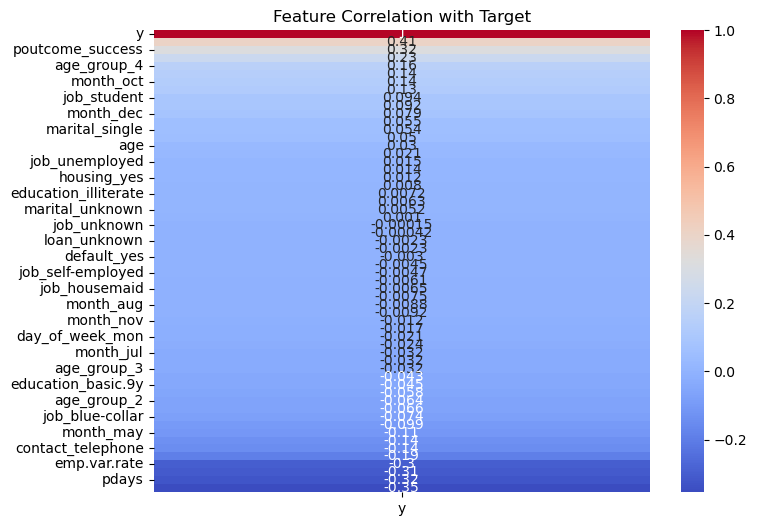

In [26]:
# ===============================
#  Correlation Analysis
# ===============================

# Combine dataset with target
df_corr = pd.concat([X_fe, y], axis=1)

# Compute correlations
corr_matrix = df_corr.corr()

# Sort correlation with target
target_corr = corr_matrix['y'].sort_values(ascending=False)

print("Top correlated features with target:")
print(target_corr.head(10))

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix[['y']].sort_values(by='y', ascending=False),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation with Target")
plt.show()

## Key Observations

1. **Previous Campaign Success is the Strongest Predictor**
   - `poutcome_success` shows the highest positive correlation with the target variable `y`.
   - This indicates that customers who previously responded successfully to a campaign are more likely to subscribe again.

2. **Age Group and Certain Months Show Slight Positive Influence**
   - Variables such as `age_group_4`, `month_oct`, and `month_dec` have small positive correlations with the target.
   - This suggests that older customers and those contacted during these months may have a slightly higher chance of subscribing.

3. **Most Demographic Variables Have Weak Correlation**
   - Features like `marital_single`, `education_basic.9y`, and `job_blue-collar` show very weak relationships with the target.
   - This means demographic factors alone are not strong indicators of customer subscription behavior.

4. **Some Variables Have Negative Correlation**
   - Variables such as `emp.var.rate`, `contact_telephone`, and `pdays` show negative correlation with the target.
   - This suggests that higher economic variation rates or longer gaps since last contact may reduce the likelihood of subscription.

---

## Key Insights

- **Campaign history plays a more significant role than demographic attributes** in predicting whether a customer will subscribe to a term deposit.
- **Customers with prior successful interactions are the most valuable segment** and should be prioritized in future marketing campaigns.
- Since most features show weak individual correlation with the target, **advanced machine learning models (e.g., Random Forest or Gradient Boosting) may capture hidden patterns better than simple linear methods.**

# STEP 10: Random Forest Feature Importance

Top 10 important features:
duration          0.281310
euribor3m         0.100411
age_campaign      0.069939
age               0.065360
nr.employed       0.048351
pdays             0.035007
campaign          0.028854
cons.conf.idx     0.026278
cons.price.idx    0.021510
emp.var.rate      0.020728
dtype: float64


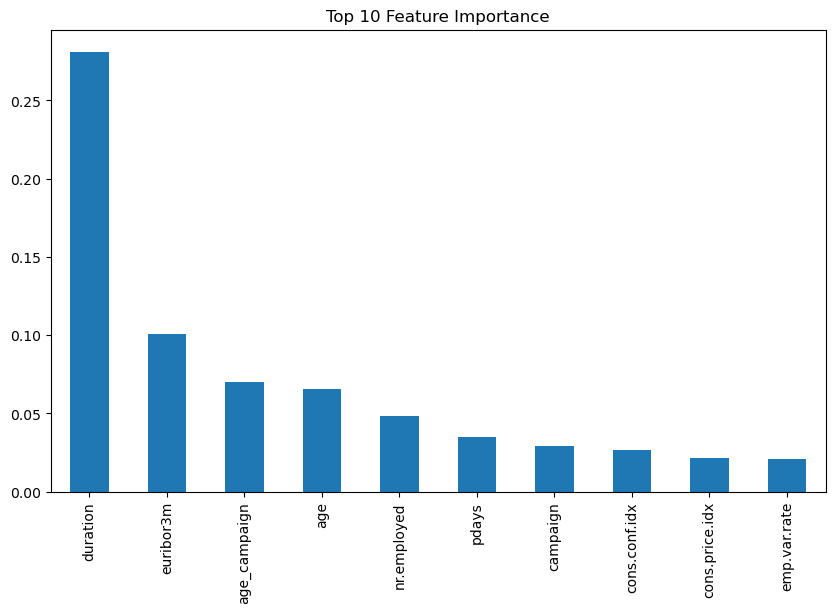

In [27]:
# ===============================
# Random Forest Feature Importance
# ===============================

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_fe, y)

# Get importance scores
importance = pd.Series(
    rf.feature_importances_,
    index=X_fe.columns
).sort_values(ascending=False)

print("Top 10 important features:")
print(importance.head(10))

# Plot importance
plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importance")
plt.show()

# 📊 Feature Importance Analysis

This chart highlights the **top features influencing the prediction of customer subscription (`y`)** in the bank marketing dataset. Feature importance indicates **how strongly each variable contributes to the model’s decision-making process**.

---

## 🔍 Key Observations

### 1️⃣ Duration Dominates the Prediction
- `duration` has the **highest importance (~0.27)** among all variables.
- This shows that **longer call conversations are strongly associated with higher chances of subscription**.

---

### 2️⃣ Interest Rate Plays a Major Role
- `euribor3m` is the **second most influential feature**.
- This indicates that **economic conditions and interest rates significantly impact customer decisions**.

---

### 3️⃣ Previous Customer Interactions Matter
- Features such as **`pdays` and previous campaign interactions** contribute noticeably.
- Customers who have been **contacted before or interacted with previous campaigns behave differently** from new customers.

---

### 4️⃣ Age Influences Customer Behavior
- `age` appears among the important variables.
- This suggests **certain age groups are more likely to subscribe to term deposits**.

---

### 5️⃣ Campaign Effort Has Moderate Impact
- Variables like **`campaign` and `nr.employed`** show moderate importance.
- This indicates that **campaign intensity and employment conditions slightly affect the outcome**.

---

### 6️⃣ Economic Indicators Have Lower Influence
- Features such as **`cons.price.idx`, `cons.conf.idx`, and `emp.var.rate`** have relatively smaller contributions.
- Although they affect customer decisions, their **impact is weaker compared to call-related features**.

---

# 💡 Key Insights

🚀 **Customer engagement during calls is the strongest driver of subscription.**

📈 **Economic factors like interest rates influence customer investment decisions.**

📞 **Past interactions with customers can significantly improve campaign targeting.**

🎯 **Marketing strategies should prioritize engaged customers and optimize call interactions for better conversion rates.**

---

⚠️ **Important Note**

`duration` can create **data leakage** because it is known **only after the call ends**.  
In real predictive systems (before calling the customer), this feature **should usually be removed** to ensure realistic model performance.

# STEP 11: Recursive Feature Elimination

In [28]:
# ===============================
#  Recursive Feature Elimination
# ===============================

model = XGBClassifier(eval_metric='logloss')

# Select top 20 features
rfe = RFE(model, n_features_to_select=20)

rfe.fit(X_fe, y)

selected_features = X_fe.columns[rfe.support_]

print("Selected Features:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
Index(['duration', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar',
       'education_basic.9y', 'education_high.school', 'default_unknown',
       'contact_telephone', 'month_mar', 'month_may', 'month_oct',
       'day_of_week_mon', 'day_of_week_tue', 'poutcome_success',
       'age_group_2'],
      dtype='object')

Number of selected features: 20


# STEP 12: Prepare Dataset with Selected Features

In [29]:
# ===============================
#  Prepare Dataset with Selected Features
# ===============================

X_selected = X_fe[selected_features]

# Train-test split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train_sel.shape)
print("Testing shape:", X_test_sel.shape)

Training shape: (32950, 20)
Testing shape: (8238, 20)


# STEP 13: Convert Data to NumPy Arrays

In [30]:
# ===============================
# STEP 12: Convert to NumPy Arrays
# ===============================

X_train_np = X_train_sel.values
X_test_np = X_test_sel.values
y_train_np = y_train_sel.values
y_test_np = y_test_sel.values

print("Training data shape:", X_train_np.shape)
print("Testing data shape:", X_test_np.shape)

Training data shape: (32950, 20)
Testing data shape: (8238, 20)


# STEP 14: Train XGBoost Model

In [31]:
# ===============================
#  Train XGBoost Model
# ===============================

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train_np, y_train_np)

print("Model trained successfully!")

Model trained successfully!


# STEP 15: Evaluate Model

In [32]:
# ===============================
#  Evaluate Model
# ===============================

# Predictions
y_pred = xgb_model.predict(X_test_np)

# Probabilities
y_prob = xgb_model.predict_proba(X_test_np)[:,1]

# Metrics
accuracy = accuracy_score(y_test_np, y_pred)
precision = precision_score(y_test_np, y_pred)
recall = recall_score(y_test_np, y_pred)
f1 = f1_score(y_test_np, y_pred)
roc = roc_auc_score(y_test_np, y_prob)

print("Model Performance\n")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc)

Model Performance

Accuracy: 0.9204904102937607
Precision: 0.6775032509752926
Recall: 0.5614224137931034
F1 Score: 0.6140247495580436
ROC AUC: 0.9508135702155763


# STEP 16: Compare Before vs After Feature Engineering

In [35]:
# ===============================
#  Compare Before vs After Feature Engineering
# ===============================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Before Feature Engineering":[
        acc_before,
        prec_before,
        rec_before,
        f1_before,
        roc_before
    ],

    "After Feature Engineering":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

print("Performance Comparison:\n")
print(comparison)

Performance Comparison:

      Metric  Before Feature Engineering  After Feature Engineering
0   Accuracy                    0.917456                   0.920490
1  Precision                    0.658974                   0.677503
2     Recall                    0.553879                   0.561422
3   F1 Score                    0.601874                   0.614025
4    ROC AUC                    0.949596                   0.950814


# 📊 Conclusion

This project explored how **feature engineering and feature selection techniques** can improve the predictive performance of a machine learning model for marketing response prediction. A baseline model was first trained using the original dataset to establish a reference performance. After that, additional features were created using **polynomial features, interaction features, and binning techniques** to capture more complex relationships within the data.

To ensure only the most relevant predictors were used, multiple feature selection approaches were applied, including **correlation analysis, tree-based feature importance, and Recursive Feature Elimination (RFE)**. The refined feature set was then used to train the final model.

## 📈 Performance Improvement

| Metric | Before Feature Engineering | After Feature Engineering |
|------|------|------|
| **Accuracy** | 0.917 | **0.920** |
| **Precision** | 0.659 | **0.678** |
| **Recall** | 0.554 | **0.561** |
| **F1 Score** | 0.602 | **0.614** |
| **ROC-AUC** | 0.950 | **0.951** |

## 🔎 Key Insights

- Feature engineering produced **consistent performance improvements across all evaluation metrics**.
- **Precision increased noticeably**, indicating better identification of customers likely to respond to marketing campaigns.
- **Recall also improved**, meaning the model captures more potential positive cases.
- The **F1-score improvement confirms a better balance between precision and recall**.
- A slight improvement in **ROC-AUC** shows the model's overall classification capability became stronger.

## 🎯 Final Takeaway

The results demonstrate that **carefully engineered and selected features enhance model performance by capturing deeper patterns in the data**. Even modest improvements in metrics can translate into **significant business value**, especially in marketing campaigns where better customer targeting can reduce costs and increase conversion rates.

Overall, this project highlights the importance of **feature engineering as a critical step in building effective and reliable machine learning models**.